In [41]:
import pickle, gzip
import numpy as np
import mplhep as hep
import matplotlib.pyplot as plt

In [2]:
hists_dict = pickle.load(gzip.open("SR_MC_2018_SMEFTsim.pkl.gz"))

In [18]:
hists = hists_dict['ee']['mllbb']
h = hists[{'channel':'ee_2b_2j', 'process':sum}]
print(h)

HistEFT(
  StrCategory(['nominal', 'elecIDUp', 'elecIDDown', 'muonIDUp', 'muonIDDown', 'muonISOUp', 'muonISODown', 'trigSFUp', 'trigSFDown', 'L1prefireUp', 'L1prefireDown', 'PUUp', 'PUDown', 'jetPuIDUp', 'jetPuIDDown', 'btagSFbc_correlatedUp', 'btagSFbc_correlatedDown', 'btagSFlight_correlatedUp', 'btagSFlight_correlatedDown', 'btagSFbc_2018Up', 'btagSFbc_2018Down', 'btagSFlight_2018Up', 'btagSFlight_2018Down', 'FSRUp', 'FSRDown', 'ISRUp', 'ISRDown', 'renormUp', 'renormDown', 'factUp', 'factDown', 'hdampUp', 'hdampDown', 'JER_2018Up', 'JER_2018Down', 'JES_AbsoluteStatUp', 'JES_AbsoluteStatDown', 'JES_AbsoluteScaleUp', 'JES_AbsoluteScaleDown', 'JES_AbsoluteMPFBiasUp', 'JES_AbsoluteMPFBiasDown', 'JES_FragmentationUp', 'JES_FragmentationDown', 'JES_SinglePionECALUp', 'JES_SinglePionECALDown', 'JES_SinglePionHCALUp', 'JES_SinglePionHCALDown', 'JES_FlavorQCDUp', 'JES_FlavorQCDDown', 'JES_FlavorPureBottomUp', 'JES_FlavorPureBottomDown', 'JES_FlavorPureCharmUp', 'JES_FlavorPureCharmDown', 'JE

In [23]:
mc_err = np.sqrt(h[{'systematic':'sumw2'}].as_hist({}).values())
print(mc_err)

[ 0.34012098  1.77396288  5.27400679  8.98140312 12.47318013 13.71344211
 12.48823254 11.61703548 10.28332709  9.3914228   7.40636392  4.43839797
  3.51858135  4.00698485  1.35984563  0.68692954]


In [29]:
nominal_yield = h[{'systematic':'nominal'}].as_hist({}).values()
sqrt_SM = np.sqrt(h[{'systematic':'nominal'}].as_hist({}).values())
print(sqrt_SM)

[ 0.82564331  4.05044311 11.32479137 20.8329688  26.5663309  30.02194589
 29.72118229 27.68644307 25.48617664 21.35844274 18.05815265 13.85595425
 10.26314167  8.89975815  5.35500986  2.75320857]


In [88]:
# h._wc_names
wc_reweight_points = []
for wc in h._wc_names:
    if 'ctG' in wc:
        wc_reweight_points.append({wc:0.5})
    else: 
        wc_reweight_points.append({wc:1.5})

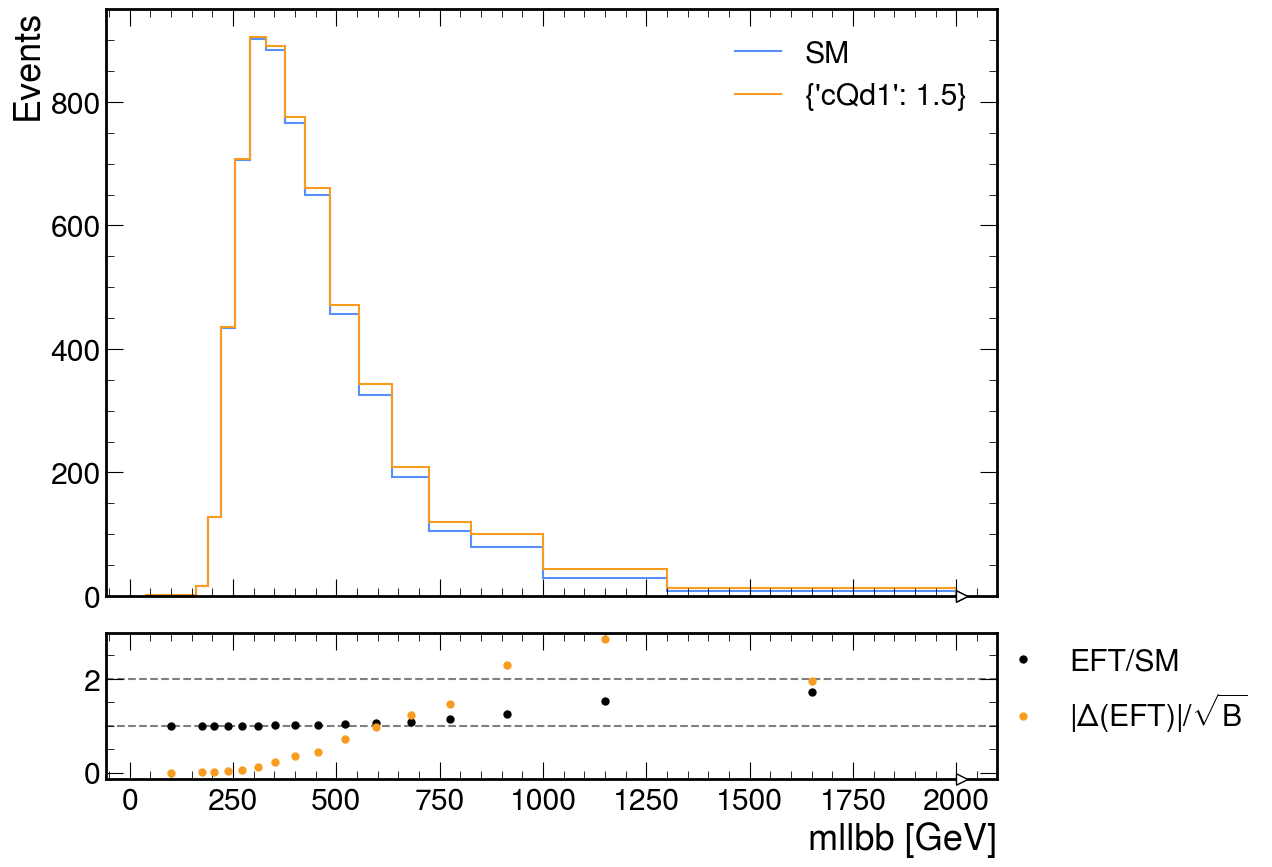

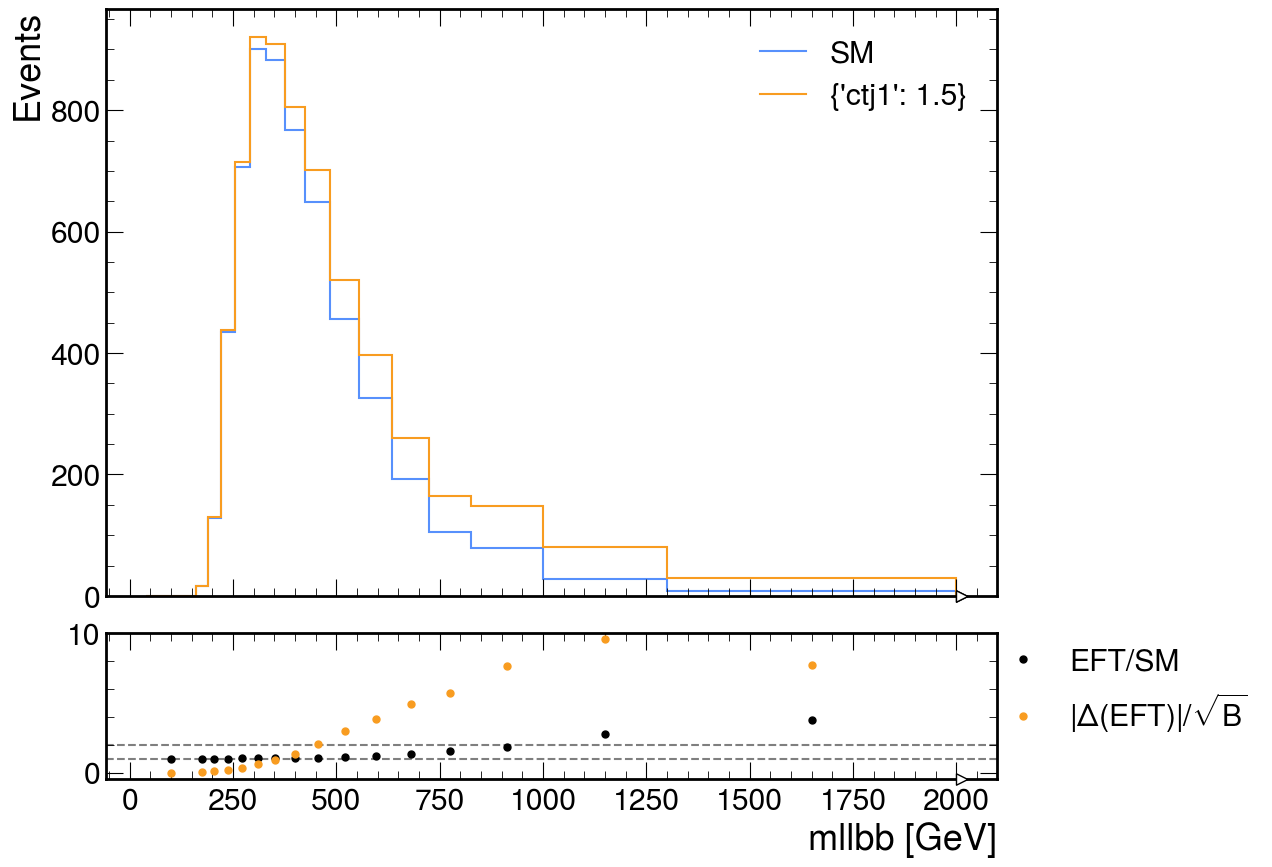

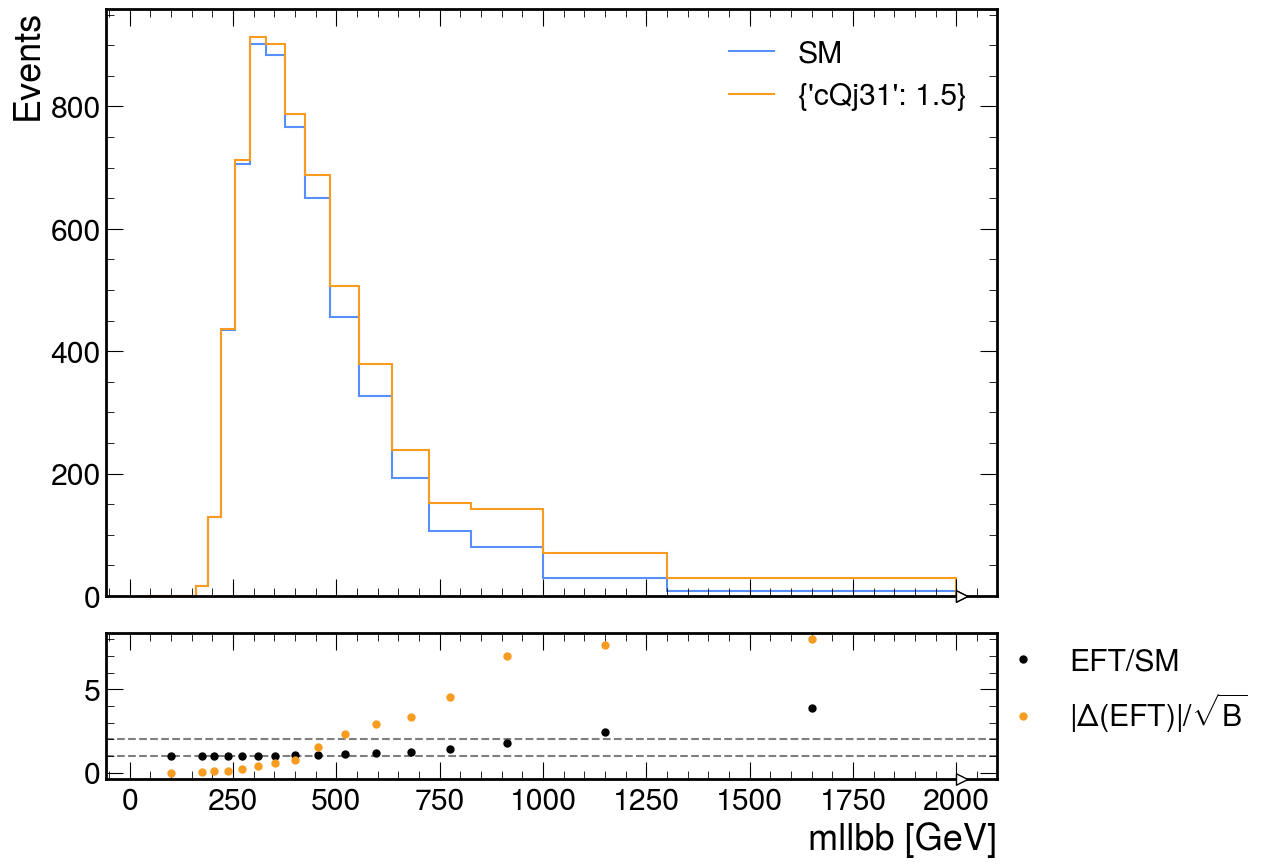

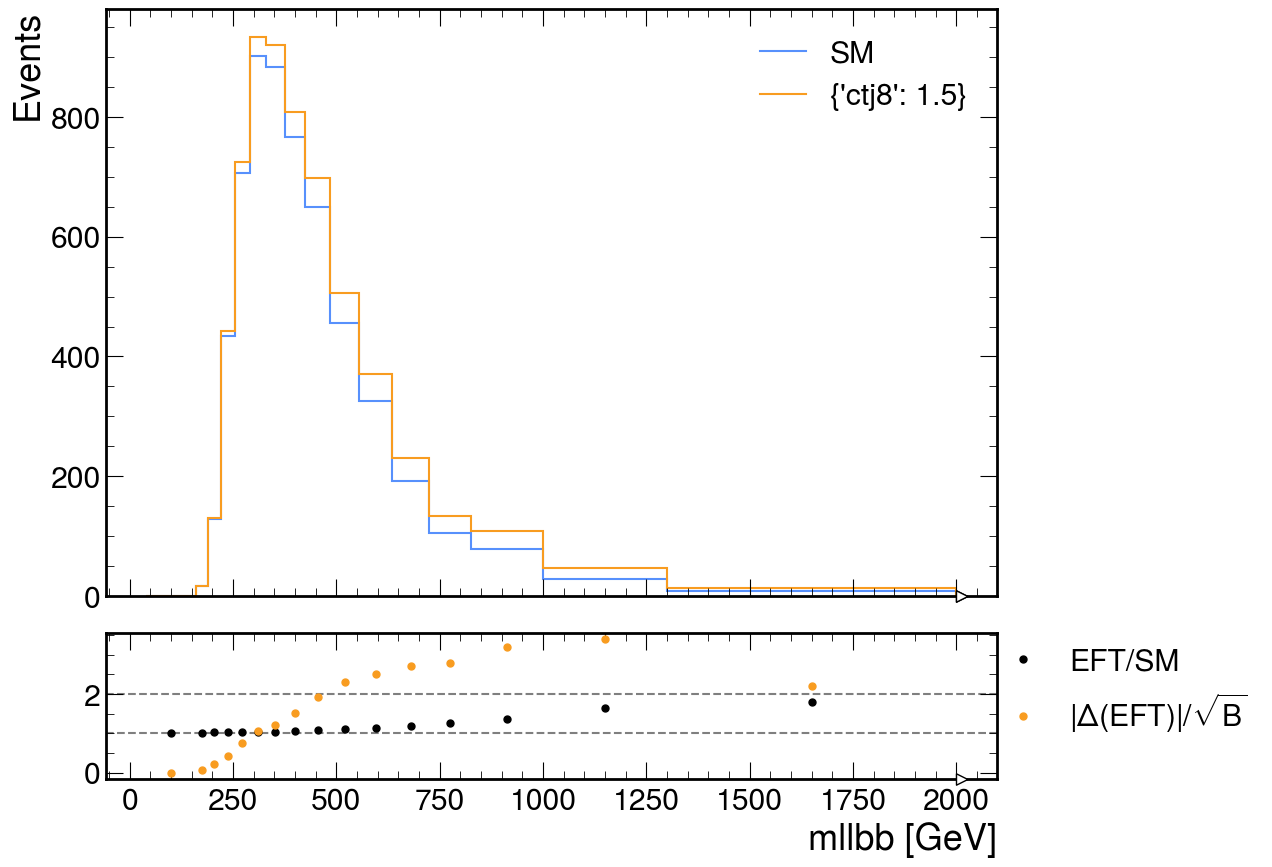

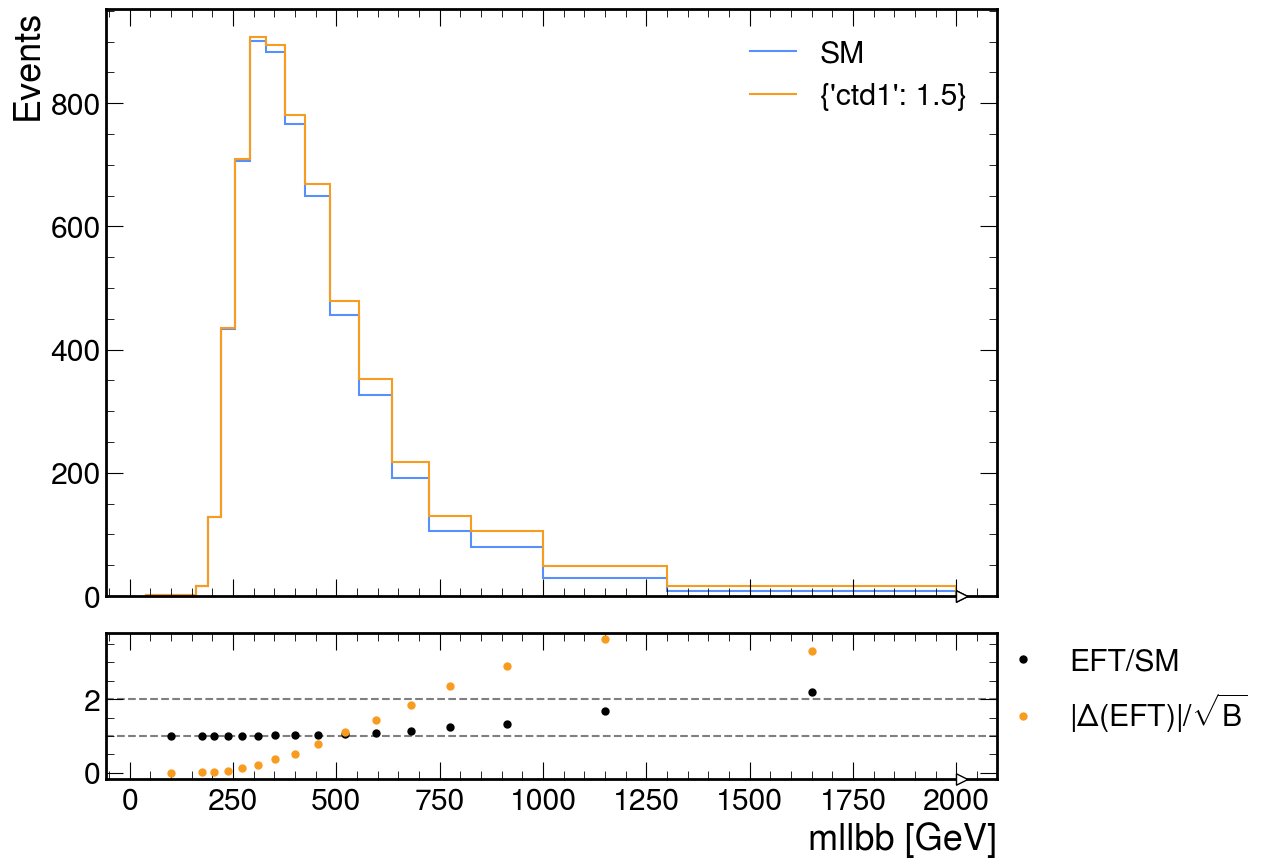

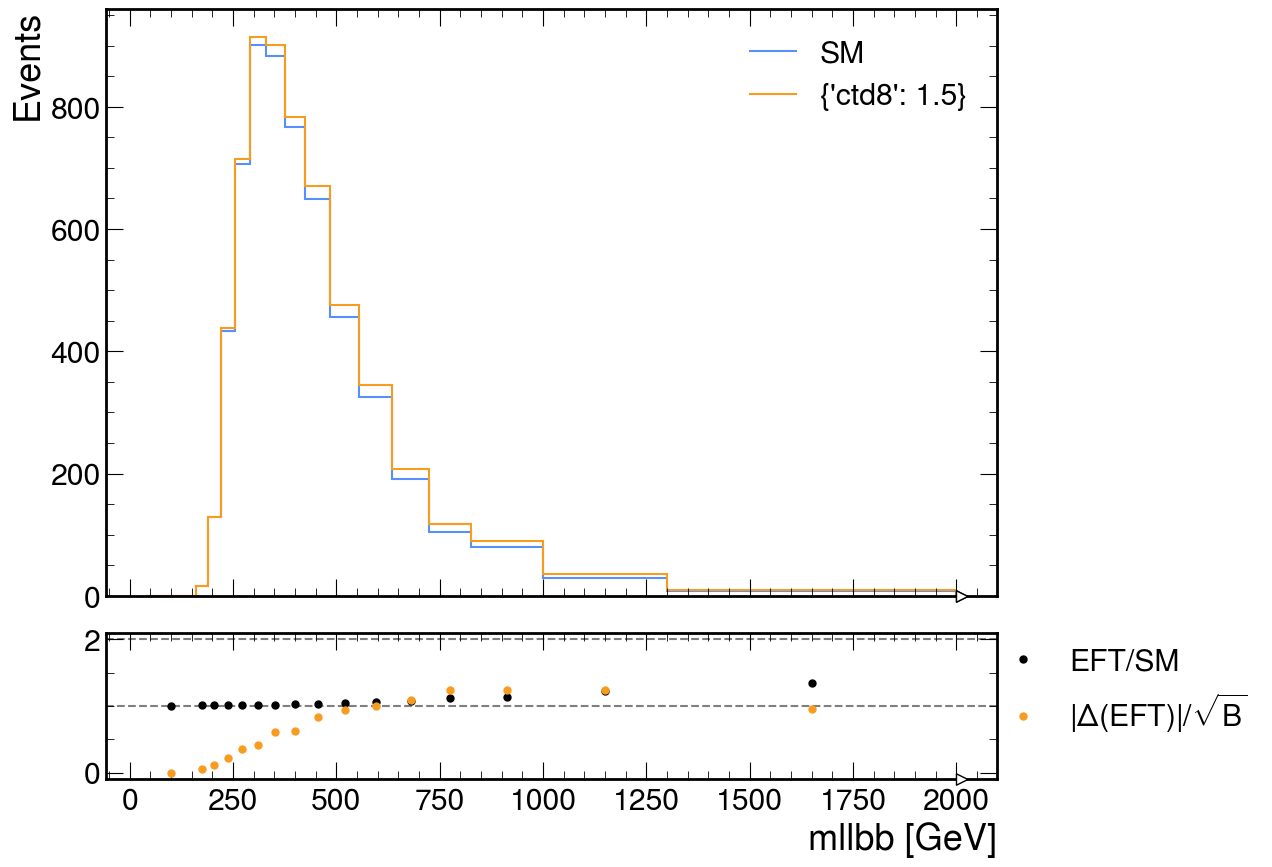

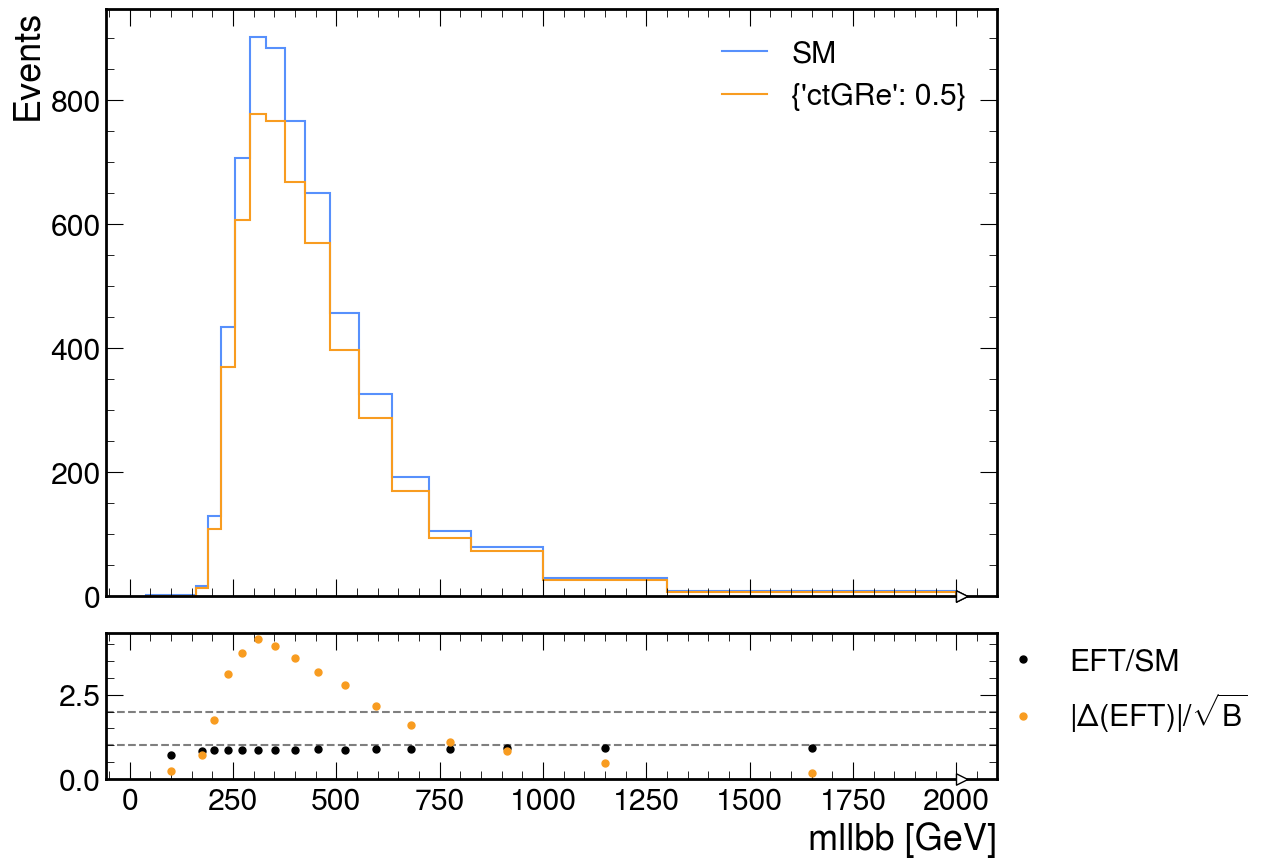

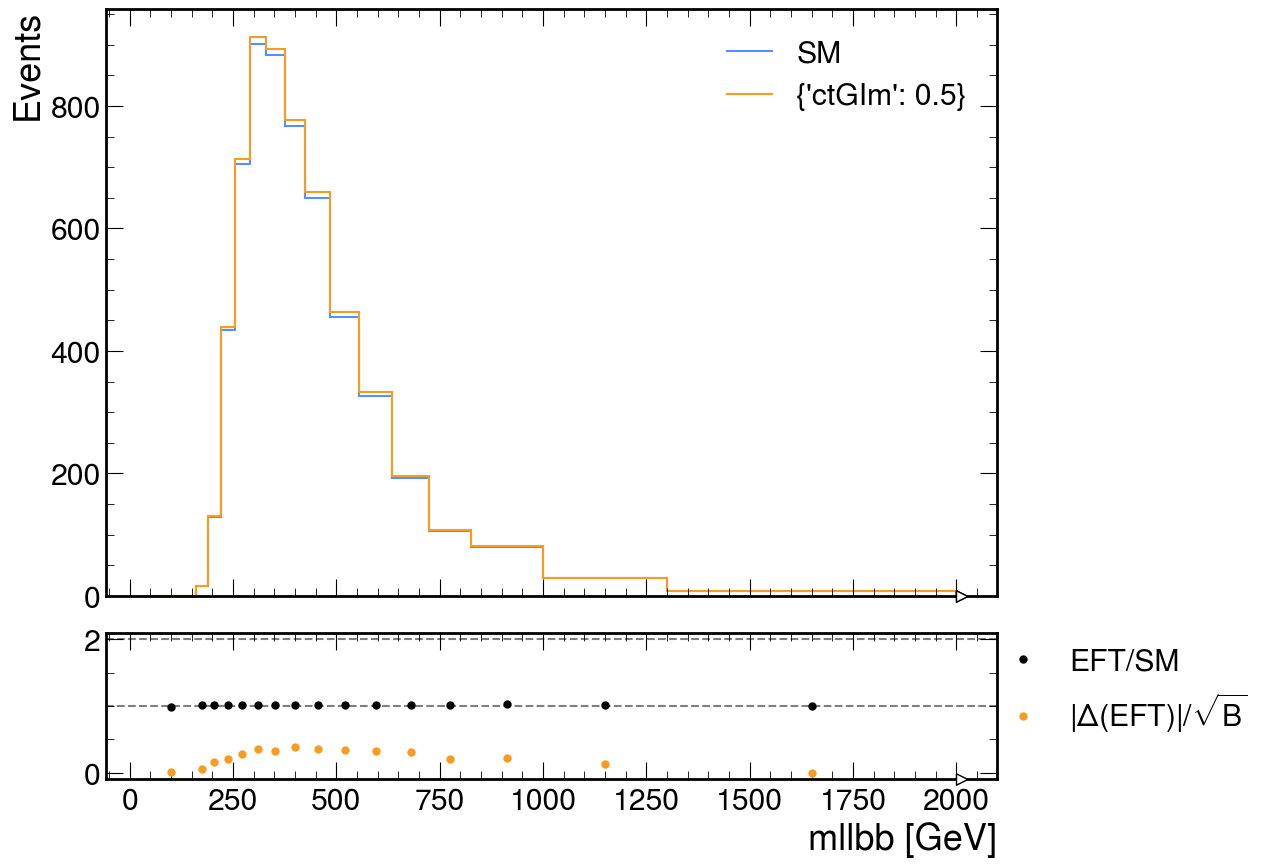

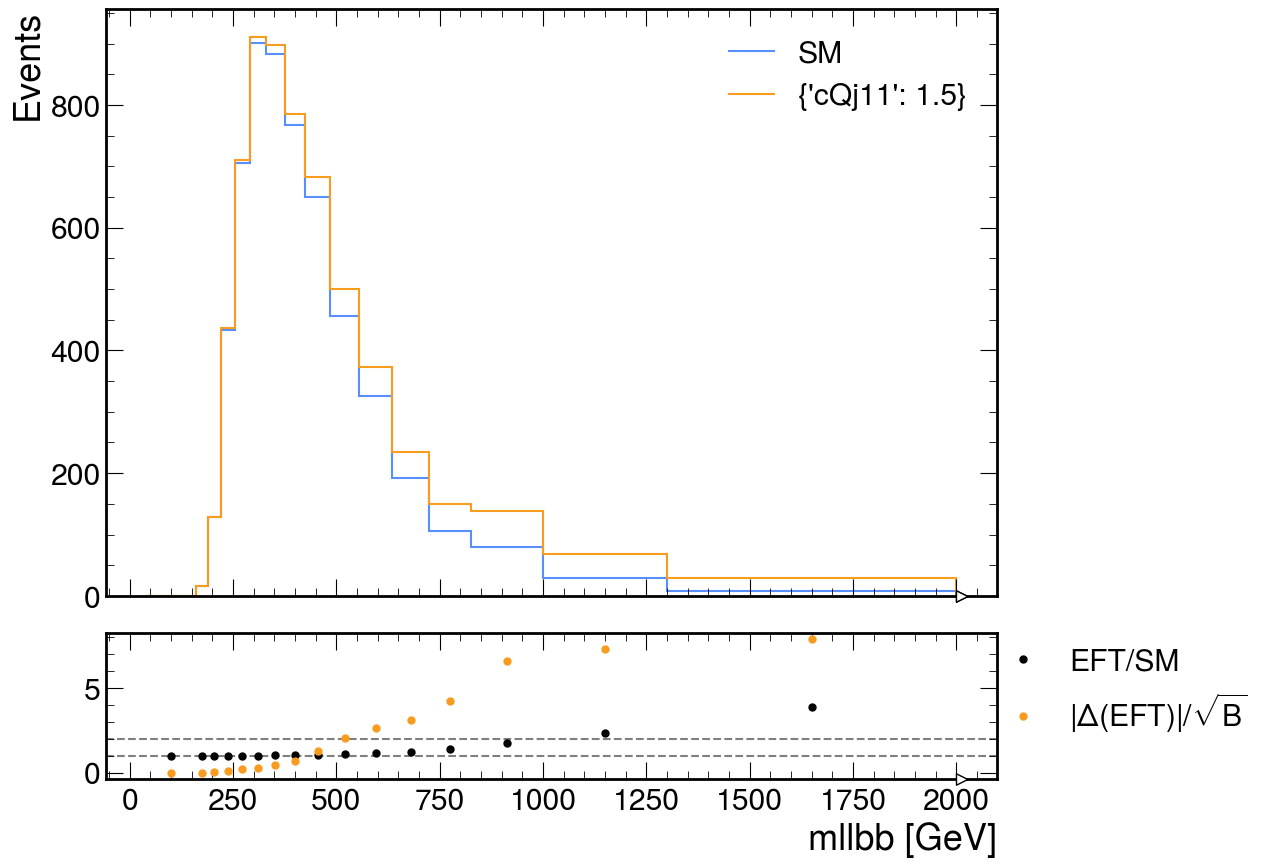

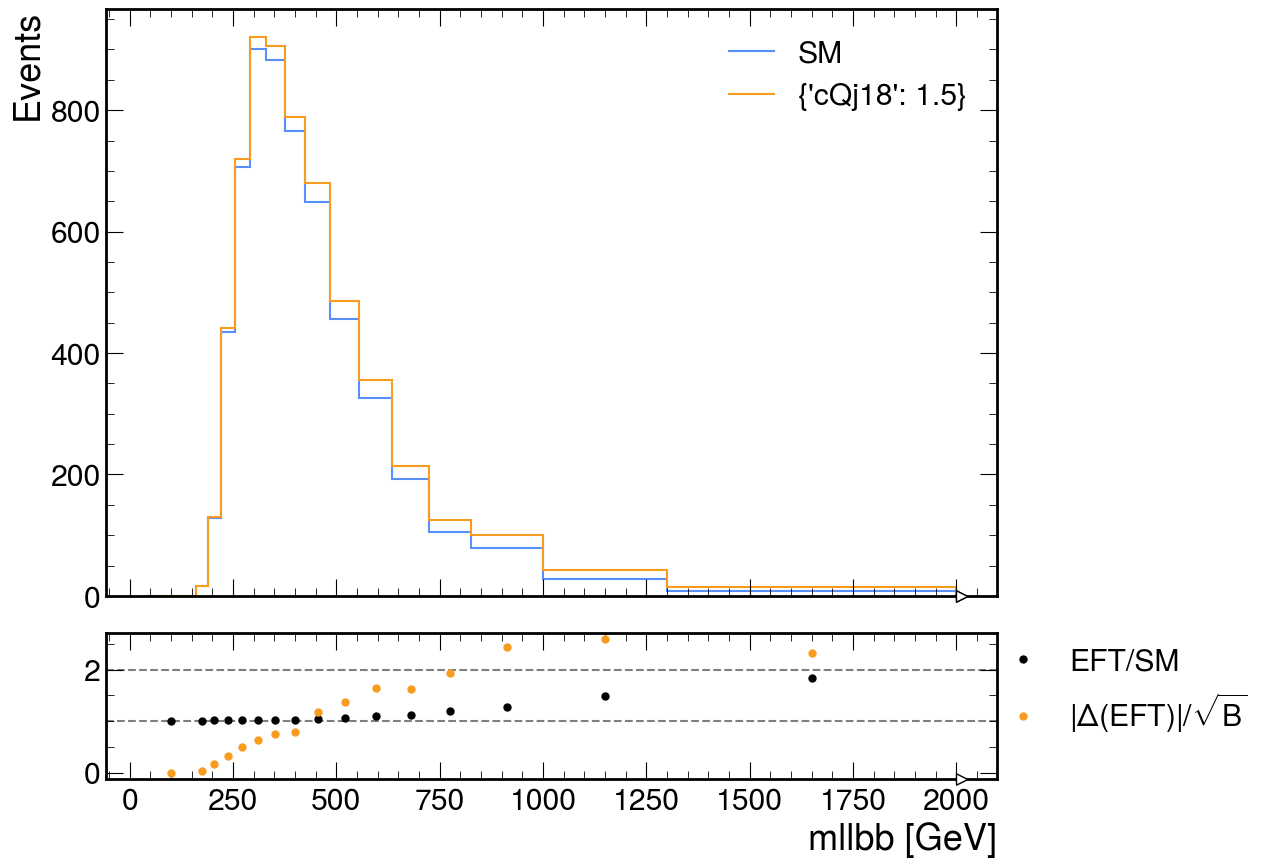

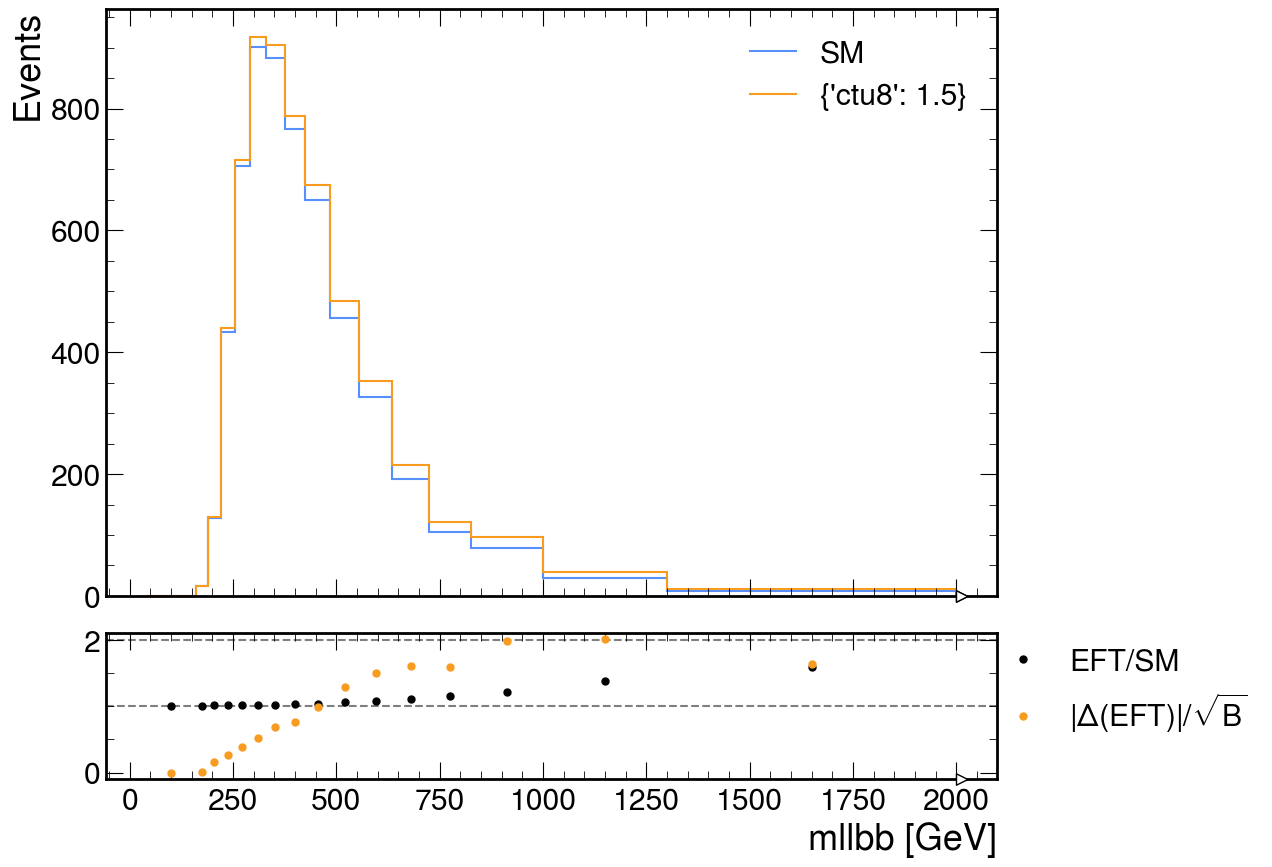

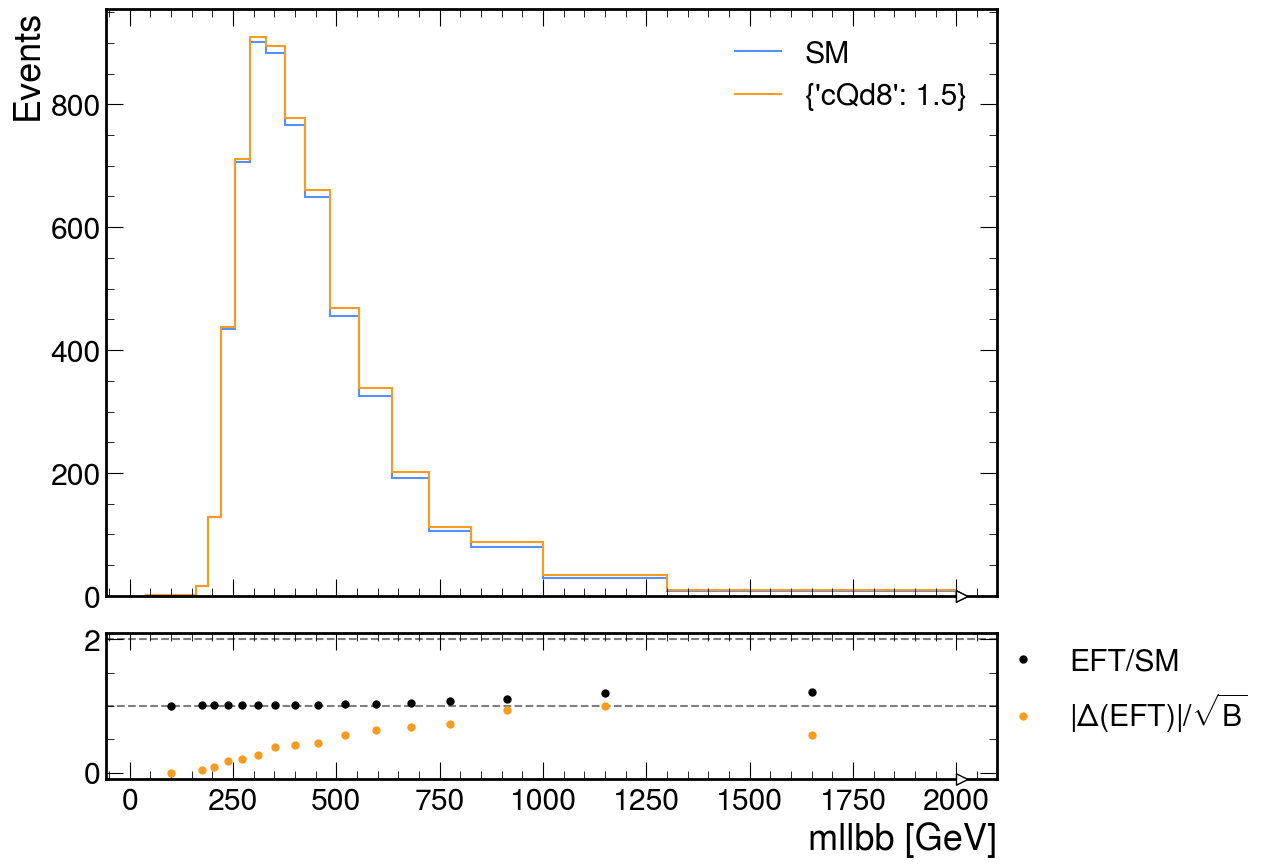

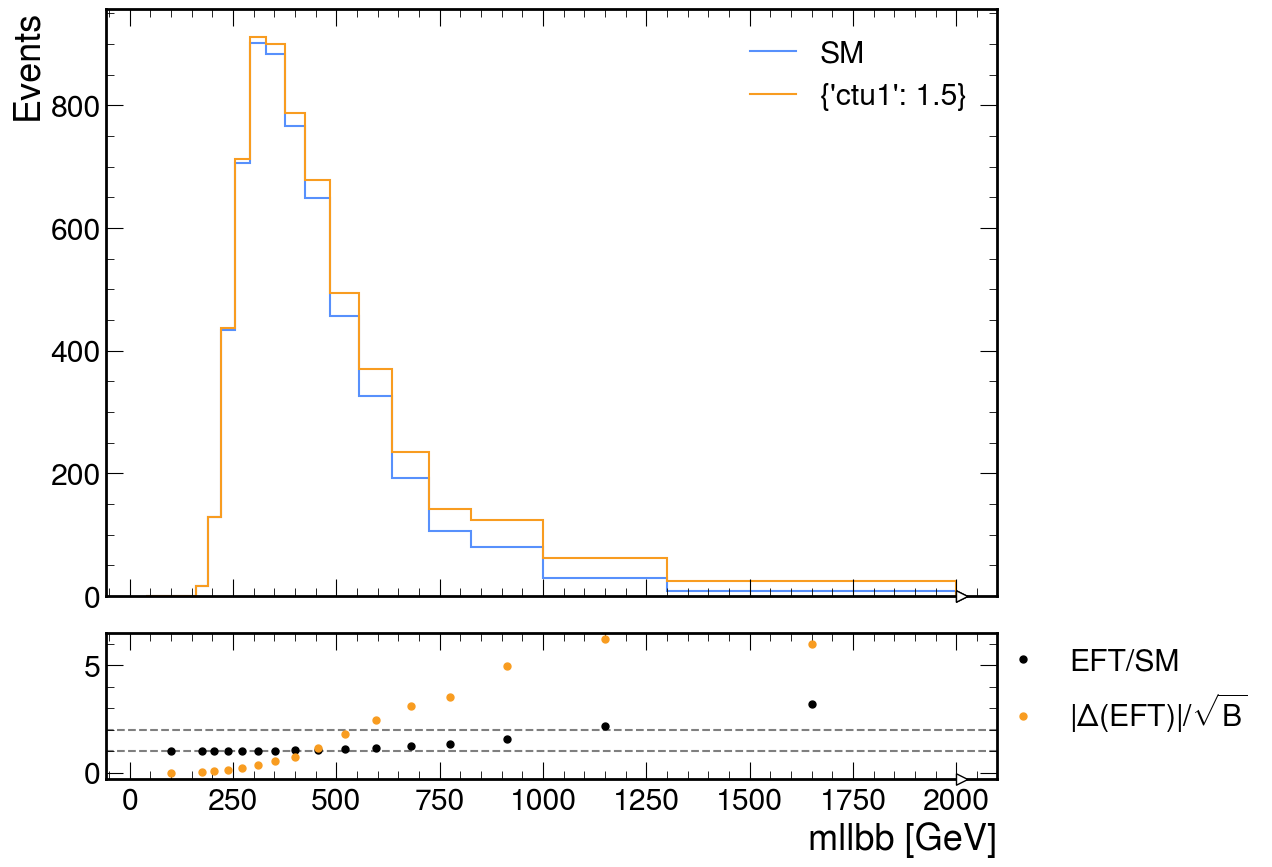

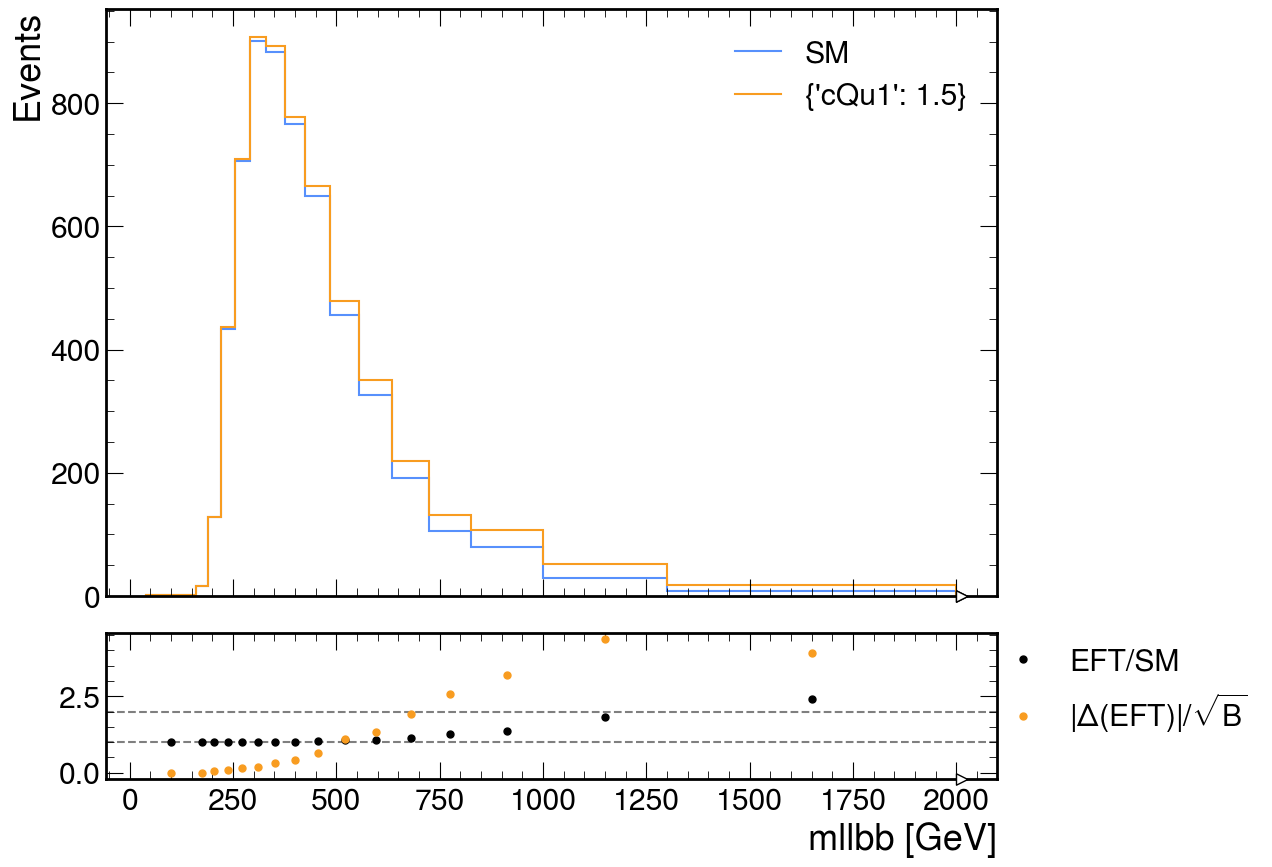

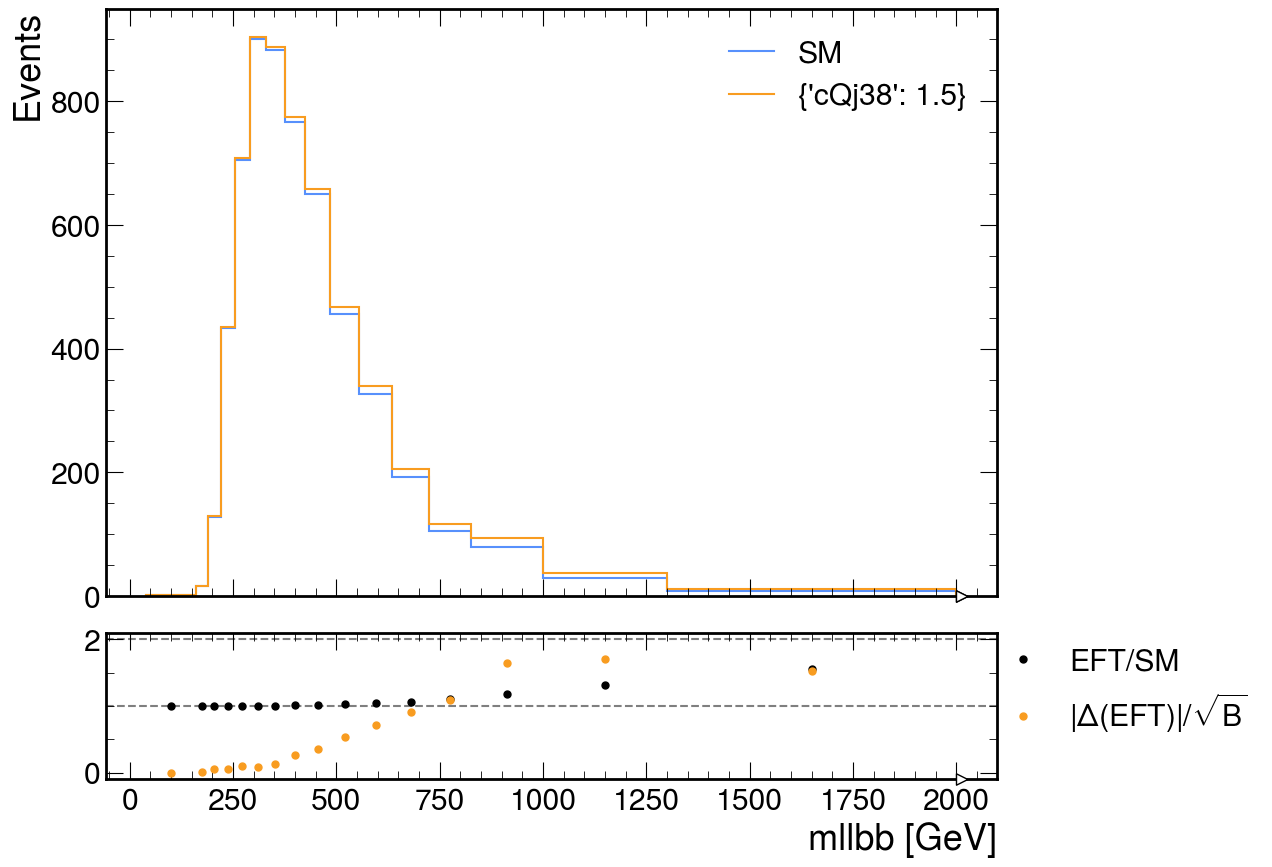

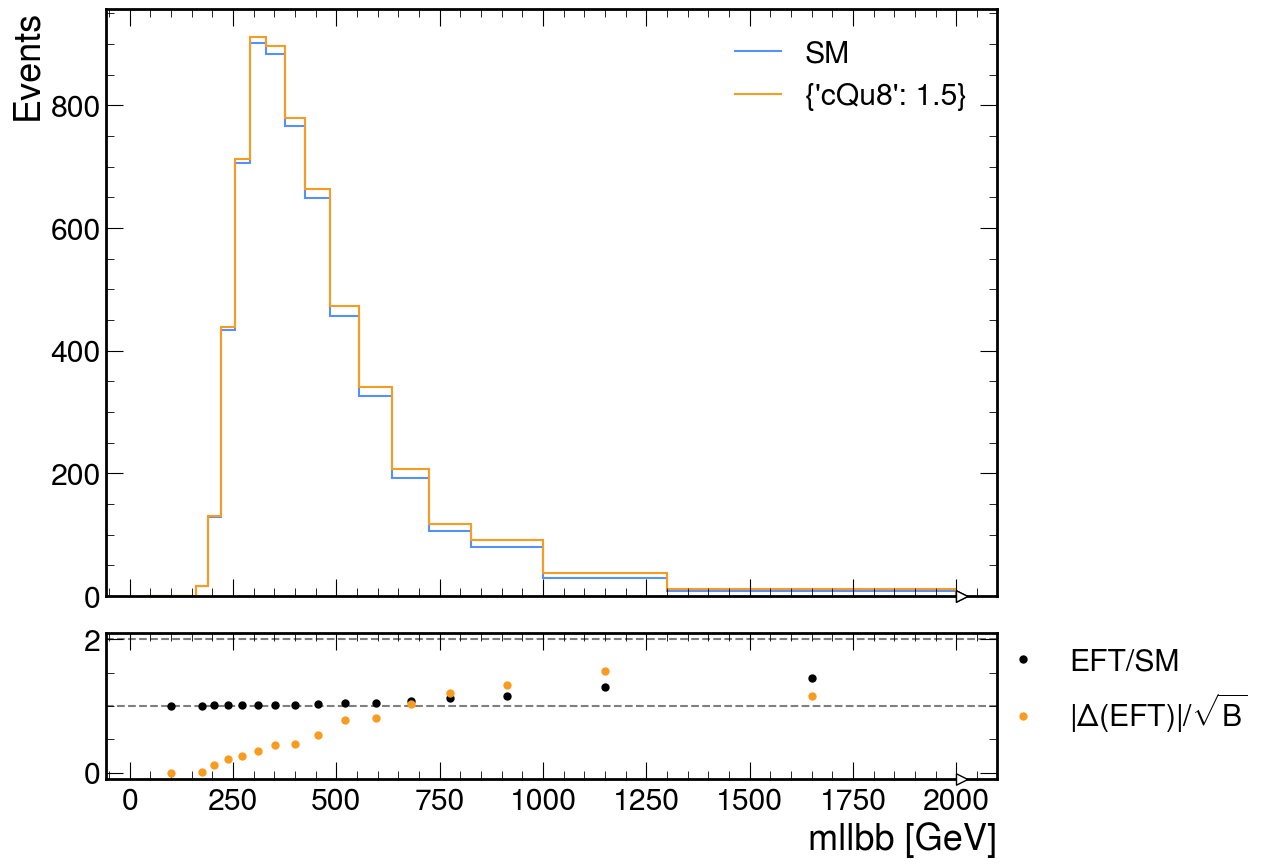

In [97]:
nominal_hist = h[{'systematic':'nominal'}].as_hist({})

for rwgt in wc_reweight_points: 
    EFT_hist = h.as_hist(rwgt)[{'systematic':'nominal'}]
    ratio = EFT_hist/nominal_hist
    SoverB_ratio = abs(EFT_hist.values()-nominal_hist.values()) / np.sqrt(nominal_hist.values())
    bin_edges = EFT_hist.axes[0].edges
    
    hep.style.use("CMS")
    fig, (ax, rax) = plt.subplots(
        nrows=2,
        ncols=1,
        figsize=(11.5,10),                                        # figsize=(10,12), # figsize=(11.5,10), figsize =(10, 10)
        gridspec_kw={'height_ratios': (4, 1), 'hspace':0.1},     # gridspec_kw={'height_ratios': (3, 1), 'hspace':0.05},
        sharex=True
    )
    
    hep.histplot(
        nominal_hist,
        stack=True,
        histtype="step",
        yerr=False,
        label="SM",
        color="#5790fc",
        ax=ax
    )
    
    hep.histplot(
        EFT_hist,
        stack=True,
        histtype="step",
        yerr=False,
        label=f"{rwgt}",
        color="#f89c20",
        ax=ax
    )
    
    hep.histplot(
        ratio,
        yerr=False,
        histtype='errorbar',
        markersize=10,
        color='black',
        label=r'EFT/SM',
        ax=rax,
    ) 
    
    hep.histplot(
        SoverB_ratio,
        bins=bin_edges,
        yerr=False,
        histtype='errorbar',
        markersize=10,
        color='#f89c20',
        # label=r'S/$\sqrt{B}$',
        label=r'|$\Delta$(EFT)|/$\sqrt{B}$',
        ax=rax,
    )  
    
    
    ax.set_xlabel("")
    # ax.set_title(f"{rwgt}")
    ax.set_ylabel("Events")
    ax.legend()
    # rax.legend(loc='best')
    rax.legend(loc='center left', bbox_to_anchor=(0.97, 0.6))
    rax.set_xlabel(nominal_hist.axes[0].label)
    # rax.set_ylim([0.8, 5])
    
    rax.axhline(y=1.0, color='black', linestyle='--', alpha=0.5)
    rax.axhline(y=2.0, color='black', linestyle='--', alpha=0.5)